<a href="https://colab.research.google.com/github/bobroberts2639/Pangolin-Security-Consulting-Services-tutte-institute-acme3/blob/main/acme3_mapping__4_hosts_as_bags_of_processes_over_time.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook #4 of the six notebooks of TutteInstitute/acm3-mapping

<img src="https://connoiter.com/images/tutte/king_tutte_on_colab.transparent_bg.png" align="left" width="200px"/>

Note: this is the fifth of the six notebooks TutteInstitute/acm3-mapping. The first one is identified as 0.

This notebook, [acme3-mapping__4_hosts_as_bags_of_processes_over_time.ipynb](https://github.com/Connoiter/king_tutte_datamap_codex/tree/main/by_repo/acme3-mapping/acme3-mapping__4_hosts_as_bags_of_processes_over_time.ipynb), is part of [the King Tutte Datamap Codex repo](https://github.com/Connoiter/king_tutte_datamap_codex), which contains a [Jupyter Book](https://jupyterbook.org/). The Jupyter notebooks in the King Tutte Datamap Codex run on Colab, and that fact is essentially the only value of this Codex work: curate and package pre-existing datamap example code and minimally modify the code to run out-of-the-box on Colab. As such, the King Tutte Datamap Codex Jupyter Book consists of King Tutte datamap pipelines that run on Google's Colab.

<br/>

## Pedigree

This notebook is simply a Colab-ified variant of [4 Hosts as bags of processes over time.ipynb](https://github.com/TutteInstitute/acme3-mapping/blob/main/4%20Hosts%20as%20bags%20of%20processes%20over%20time.ipynb), which is part of the Tutte Institute's repo, [acme3-mapping](https://github.com/TutteInstitute/acme3-mapping).

## What this notebook does

<img src="https://user-images.githubusercontent.com/50601643/218871643-2d3af433-0923-4786-b5e5-24c6a72e803e.png" align="right" height="100px"/>

Lawrence Livermore National Laboratory (LLNL) has produced a tool, [Wintap](https://github.com/LLNL/Wintap), which is [MIT licensed](https://github.com/llnl/Wintap/blob/main/LICENSE). As part of that project, they currated some test data, as explained on [a LLNL website](https://gdo168.llnl.gov/). One of those datasets is known as [ACME 3](https://gdo168.llnl.gov/data/ACME3/). These six notebooks apply King Tutte pipelines to the ACME 3 dataset in order to demonstrate how they can be used to diagnose hacks of Windows networks.

In Notebook #0, the recorded commandlines of ACME 3 were tokenized. In Notebook #1 they were naively datamapped. This notebooke produces a datamap which views a host as a bag of processes.

For the fullest explanation of these six notebooks, watch the 34 minute recording of a SciPy 2024 talk by [one of the authors of the original six notebooks](https://github.com/TutteInstitute/acme3-mapping/graphs/contributors), Benoit Hamelin of the Tutte Institute:

[![Vector space embeddings and data maps for cyber defense](https://img.youtube.com/vi/j1w4WHgtfDg/maxresdefault.jpg)](https://www.youtube.com/watch?v=j1w4WHgtfDg)

For more info, see [the King Tutte repo's acme3-mapping readme](https://github.com/Connoiter/king_tutte_datamap_codex/tree/main/by_repo/acme3-mapping).


For more info (including a long video explanation), see [the repo's acme3-mapping readme](https://github.com/Connoiter/king_tutte_datamap_codex/tree/main/by_repo/acme3-mapping).


# Embedding hosts as distributions on point clouds of process instances

An interesting insight on representing objects with vectors is that they enable _hierarchical_ vector space embeddings.
Indeed, if one has a hierarchy of objects containing each other,
then a vector representation of the innermost objects can be lifted back up through a sequence of Wasserstein embeddings of the container layers.

Concretely, we have process instances, attached to command lines.
On the one hand, command lines (and thus process instances) _contain_ a set of tokens.
On the other hand, processes run on hosts at a specific time;
said differently, hosts, over a certain time interval, _contain_ a set of process instances.
So, since we have a vector space embedding of process instances (command lines really),
we can get a vector representation of hosts as distributions on a point cloud of process instances.
<a id="interpretation"></a>
Thus hosts, in a time interval, would accrete into clusters when they run similar process workloads.

---

Goals of this notebook:

1. Compute a vector representation of hosts in a sequence of time intervals.
2. Appraise these vectors in a flat data map.
3. Derive a naïve visualization of the behaviour of a single host over time.

---

**Attention**: results from [notebook 2](Command%20lines%20-%20Wasserstein%20embedding.ipynb) are required for what follows, so run that notebook first.

In [ ]:
# Set this "CONSTANT" to wherever on Hugging Face the output Parquet files of Notebook #0 is.
# "connoiter/acme3-mapping" works as is because Connoiter has previously parked
# the data on Hugging Face.
REPO_ID_OF_DATA_ON_HUGGING_FACE = "connoiter/acme3-mapping-TEMP"

## Install Tutte Institute packages

The original TutteInstitute/acm3-mapping notebooks assume that various Tutte Institute tools get installed via `environment.yml` which is not the case on Colab. So to get this to work on Colab, Connoiter added in the following `pip install` commands.

In [ ]:
!pip install umap-learn
!pip install datamapplot
!pip install vectorizers
!pip install fast_hdbscan
!pip install glasbey

In [ ]:
import datamapplot as dmp
from fast_hdbscan import HDBSCAN
import glasbey
from IPython.display import Video
from matplotlib import colormaps
from matplotlib.animation import FuncAnimation
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.signal
import scipy.sparse
from tqdm.auto import trange, tqdm
import umap
import vectorizers as vz
import vectorizers.transformers as vzt

## Download intermediate data from Hugging Face

The original Tutte Institute notebook assumes that files generated by earlier notebooks (#0, #1, #2) are sitting in the localhost file system. That is not the case on Colab (on Colab all notebooks are run on new runtimes; file system state is not persisted between notebooks as is the case with, say, Jupyter Lab), so Connoiter has been saving intermediate product files off to Hugging Face. Now we need to download those Parquet files to make the rest of Tutte's code run as-was.


In [ ]:
from huggingface_hub import hf_hub_download

def download_from_huggingface(repo_id, filename):
    hf_hub_download(
        repo_id=repo_id,
        local_dir=".",
        filename=filename
    )

download_from_huggingface(REPO_ID_OF_DATA_ON_HUGGING_FACE, "process_filtered.parquet")

download_from_huggingface(REPO_ID_OF_DATA_ON_HUGGING_FACE, "image_loads.parquet")
download_from_huggingface(REPO_ID_OF_DATA_ON_HUGGING_FACE, "cmdlines_iwt.npz")
download_from_huggingface(REPO_ID_OF_DATA_ON_HUGGING_FACE, "cmdlines_bagofwords.npz")
download_from_huggingface(REPO_ID_OF_DATA_ON_HUGGING_FACE, "cmdlines_labels_hovertext.parquet")
download_from_huggingface(REPO_ID_OF_DATA_ON_HUGGING_FACE, "color_map.json")
download_from_huggingface(REPO_ID_OF_DATA_ON_HUGGING_FACE, "cmdlines_wasserstein.npz")
download_from_huggingface(REPO_ID_OF_DATA_ON_HUGGING_FACE, "cmdlines_unique.npz")

Gather our processes.

In [ ]:
processes = pd.read_parquet("process_filtered.parquet")
processes

,pid_hash,parent_pid_hash,timestamp,hostname,name,cmdline,ptree
0,D344D3D1AB4DB23FA8E3A27747512683,4077531090546BF97B77D5D1B84886C7,2023-11-05 00:00:01.665756+00:00,ACME-DC1,wsqmcons.exe,"""c:\windows\system32\wsqmcons.exe""",=wsqmcons.exe->svchost.exe->services.exe->wini...
1,66BB0D55AF9EFDAA3201581D11EE7E0F,DCAE2AF494F63EC152DDFB7703B61486,2023-11-05 00:00:27.954172+00:00,ACME-WS-PRV,mousocoreworker.exe,"""c:\windows\system32\mousocoreworker.exe"" -emb...",=mousocoreworker.exe->svchost.exe->services.ex...
2,9D791FE57826CC963DFC2B0206EEF028,BA7EC59E059F8E7B9F75D3BD0D3E85FE,2023-11-05 00:00:59.436929+00:00,ACME-HH-YIM,taskhostw.exe,"""c:\windows\system32\taskhostw.exe"" system",=taskhostw.exe->svchost.exe->services.exe->win...
3,229A30ADEECFAA4CCFE262353A7FFDEA,6DB651F1EAD84F88801332945F69A5F2,2023-11-05 00:01:02.292882+00:00,ACME-HH-TTW,taskhostw.exe,"""c:\windows\system32\taskhostw.exe"" system",=taskhostw.exe->svchost.exe->services.exe->win...
4,9823D281D913FA438D444761F0939A4E,7E181521E18EE9BF804A63C1ED93F465,2023-11-05 00:01:07.597761+00:00,ACME-HH-OLY,taskhostw.exe,"""c:\windows\system32\taskhostw.exe"" system",=taskhostw.exe->svchost.exe->services.exe->win...
...,...,...,...,...,...,...,...
137842,11D2905584ADEBDB004263B08D3706A1,5B1453B37F079EC6AA910E820C5B6BF1,2023-11-20 23:54:14.616846+00:00,ACME-HH-IKA,usoclient.exe,"""c:\windows\system32\usoclient.exe"" startscan",=usoclient.exe->svchost.exe->services.exe->win...
137843,D8DC51881EDB5C6F7D6239E3DE1A5D93,E283B625D417A1C9584B2D6C9D0C364F,2023-11-20 23:54:14.638486+00:00,ACME-HH-IKA,mousocoreworker.exe,"""c:\windows\system32\mousocoreworker.exe"" -emb...",=mousocoreworker.exe->svchost.exe->services.ex...
137844,521490D4B45E5BDC4BD2CA7081BC06A7,6A37E544F4D9E91016071993B3DC4103,2023-11-20 23:55:23.333011+00:00,ACME-HH-AZH,usoclient.exe,"""c:\windows\system32\usoclient.exe"" startscan",=usoclient.exe->svchost.exe->services.exe->win...
137845,D2211D916C3414FDFBD2663BB9051C84,2C2DB3363D7539099C7869C6BFEEED6B,2023-11-20 23:55:23.349693+00:00,ACME-HH-AZH,mousocoreworker.exe,"""c:\windows\system32\mousocoreworker.exe"" -emb...",=mousocoreworker.exe->svchost.exe->services.ex...


Get the better command line vectors.

In [ ]:
cmdlines_vec = np.load("cmdlines_wasserstein.npz")["cmdlines"]
cmdlines_vec.shape

(31046, 512)

So our command line vectors were derived with _uniqued_ command lines.
We want to take into account _all_ process instances here, so let's tie the index to each command line vector back to the process instance record.

In [ ]:
with np.load("cmdlines_unique.npz") as store_cmdlines_unique:
    i_unique = store_cmdlines_unique["i_unique"]
    i_deunique = store_cmdlines_unique["i_deunique"]
processes_indexed = processes[["name", "pid_hash", "hostname"]].copy()
processes_indexed["timestamp"] = processes["timestamp"].dt.tz_convert("-0500")
processes_indexed["index_vec"] = i_deunique
processes_indexed

,name,pid_hash,hostname,timestamp,index_vec
0,wsqmcons.exe,D344D3D1AB4DB23FA8E3A27747512683,ACME-DC1,2023-11-04 19:00:01.665756-05:00,30210
1,mousocoreworker.exe,66BB0D55AF9EFDAA3201581D11EE7E0F,ACME-WS-PRV,2023-11-04 19:00:27.954172-05:00,28653
2,taskhostw.exe,9D791FE57826CC963DFC2B0206EEF028,ACME-HH-YIM,2023-11-04 19:00:59.436929-05:00,29522
3,taskhostw.exe,229A30ADEECFAA4CCFE262353A7FFDEA,ACME-HH-TTW,2023-11-04 19:01:02.292882-05:00,29522
4,taskhostw.exe,9823D281D913FA438D444761F0939A4E,ACME-HH-OLY,2023-11-04 19:01:07.597761-05:00,29522
...,...,...,...,...,...
137842,usoclient.exe,11D2905584ADEBDB004263B08D3706A1,ACME-HH-IKA,2023-11-20 18:54:14.616846-05:00,30077
137843,mousocoreworker.exe,D8DC51881EDB5C6F7D6239E3DE1A5D93,ACME-HH-IKA,2023-11-20 18:54:14.638486-05:00,28653
137844,usoclient.exe,521490D4B45E5BDC4BD2CA7081BC06A7,ACME-HH-AZH,2023-11-20 18:55:23.333011-05:00,30077
137845,mousocoreworker.exe,D2211D916C3414FDFBD2663BB9051C84,ACME-HH-AZH,2023-11-20 18:55:23.349693-05:00,28653


And now, count instances of each command line by host and by time interval.
First group process instances by host,
then `resample` the process instance timestamps in 3-hour bins.
We also ensure to reject all process instances that might formally be outside of the data capture period &mdash;
we seem to have some instances timestamped prior to November 5 2023, midnight EST.
The baroque pandasism that follows handles that.

In [ ]:
%%time
processes_x_host_time = pd.concat([
    (
        group
        .resample(pd.Timedelta(hours=3), on="timestamp", origin=pd.Timestamp("2023-11-05", tz="-0500"))
        .agg({
            "index_vec": lambda x: list(pd.Series(x).value_counts().items()) or np.nan,
            "pid_hash": lambda x: list(x) or np.nan
        })
        .assign(hostname=hostname)
        .reset_index()
    )
    for hostname, group in processes_indexed.groupby("hostname")
]).dropna().sort_values(["timestamp", "hostname"]).reset_index(drop=True)
processes_x_host_time

CPU times: user 1.1 s, sys: 5.69 ms, total: 1.11 s
Wall time: 1.14 s


,timestamp,index_vec,pid_hash,hostname
0,2023-11-04 18:00:00-05:00,"[(28653, 2), (6973, 2), (29474, 2), (29492, 2)...","[D344D3D1AB4DB23FA8E3A27747512683, 2C77E664D60...",ACME-DC1
1,2023-11-04 18:00:00-05:00,"[(6973, 3), (28129, 3), (28653, 2), (29492, 2)...","[3EA7532AA31F68D930E892AC171A8F43, 0E7FD4B7860...",ACME-HH-AKA
2,2023-11-04 18:00:00-05:00,"[(6973, 3), (28653, 3), (29515, 2), (29492, 2)...","[B9C55C1CB778DABD687221352ADB466A, 252DC4E0A16...",ACME-HH-AXF
3,2023-11-04 18:00:00-05:00,"[(6973, 3), (28653, 2), (29492, 2), (29506, 2)...","[4D1FF52B86791FE6F0D28EB30B384C71, 8FB43722FF5...",ACME-HH-AZH
4,2023-11-04 18:00:00-05:00,"[(29492, 2), (28653, 2), (6973, 2), (29459, 1)...","[FBFB7697E82EBEE75A9DB89846785692, CE1C3AFBA1F...",ACME-HH-CCF
...,...,...,...,...
2584,2023-11-20 15:00:00-05:00,"[(29506, 6), (26535, 6), (28129, 3), (29492, 3...","[9B184238C4B3508C44A0889548CE38EA, 8C4F00E4E8B...",ACME-HH-IQS
2585,2023-11-20 18:00:00-05:00,"[(3110, 1), (6227, 1), (29506, 1), (26535, 1),...","[8DDE6F47DB90619F86BD14A16F98CEE2, 9BD3697DCEA...",ACME-DC1
2586,2023-11-20 18:00:00-05:00,"[(28653, 2), (28129, 1), (28944, 1), (29497, 1...","[5BB26EE4E63E3CE44E7FFAB5A0E6E321, AE736B4B16B...",ACME-HH-AZH
2587,2023-11-20 18:00:00-05:00,"[(28653, 2), (28129, 1), (28944, 1), (29497, 1...","[2B81182F7C23BE3D4A934313D3FCB52B, A15DA5AF705...",ACME-HH-IKA


Ok, so we have the command line vectors, what we are missing are the weighted distributions.
Each row of `processes_x_host_time` above represents a (host, time interval) couple &mdash; let's call these _host-times_.
The `index_vec` column contains a list of (command line index, count) for each of these host-times.
Since host-times are expressed over the vocabulary of (vector-represented) command lines,
these are essentially the elements we need to build the count matrix.
If we [explode](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.explode.html) the `index_vec` column,
each row of the resulting data frame contains a triple of the form

```
(row identifier, column identifier, count)
```

A list of such triples suffices to build up the count matrix in a [sparse COO format](https://matteding.github.io/2019/04/25/sparse-matrices/#coordinate-matrix).
We have the `vectorizers.EdgeListVectorizer` to render this.
Notice that we are forcing the column space to match the full set of command line indices.
This is because otherwise, `EdgeListVectorizer` realizes that some command line indices are not used between minimum and maximum observed indices, and discards the corresponding columns.
Forcing the existence of these empty columns makes it easier to match counts back to our vectors.

In [ ]:
%%time
vz_tc = vz.EdgeListVectorizer(column_label_dictionary={i: i for i in range(len(cmdlines_vec))}).fit([
    ((t.timestamp, t.hostname), *t.index_vec)
    for t in processes_x_host_time.explode("index_vec").dropna().itertuples(index=False)
])
pxht_tc = vz_tc._train_matrix.tocsr()
pxht_tc

CPU times: user 44.4 s, sys: 121 ms, total: 44.5 s
Wall time: 57.8 s


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 75124 stored elements and shape (2589, 31046)>

Modulate counts by information contribution.

In [ ]:
%%time
pxht_iwt = vzt.InformationWeightTransformer().fit_transform(pxht_tc)
pxht_iwt

CPU times: user 1.95 s, sys: 29.5 ms, total: 1.98 s
Wall time: 2.07 s


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 75124 stored elements and shape (2589, 31046)>

Now we have what we need to vectorize the host-times.

In [ ]:
%%time
pxht_vec = vz.WassersteinVectorizer().fit_transform(pxht_iwt, vectors=cmdlines_vec)
pxht_vec

CPU times: user 30.4 s, sys: 1.25 s, total: 31.7 s
Wall time: 26 s


array([[ 1.31238407,  9.00213325, -2.14375864, ...,  0.34491505,
        -0.06518477,  0.20074612],
       [ 6.80715665,  1.69234447, -0.44156496, ...,  0.09000552,
         0.52213288, -0.21036919],
       [ 7.00158636,  2.43132515, -0.51805059, ...,  0.11249476,
         0.06884184,  0.12562809],
       ...,
       [ 3.36271117,  6.58558609, -2.47302206, ...,  0.20346207,
         0.98706826, -0.23384494],
       [ 4.45212237,  4.29176061, -3.05443225, ...,  0.89766099,
         0.17261523,  0.10732863],
       [ 3.04819505,  6.24841558, -0.91005661, ...,  0.12322322,
         0.60293605, -0.1887875 ]])

Compress these vectors into a data map.

In [ ]:
%%time
pxht_dmap = umap.UMAP(metric="cosine", verbose=True).fit_transform(pxht_vec)

UMAP(angular_rp_forest=True, metric='cosine', verbose=True)
Wed Jul 15 04:19:47 2026 Construct fuzzy simplicial set
Wed Jul 15 04:19:54 2026 Finding Nearest Neighbors
Wed Jul 15 04:19:57 2026 Finished Nearest Neighbor Search
Wed Jul 15 04:20:02 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Wed Jul 15 04:20:08 2026 Finished embedding
CPU times: user 22.5 s, sys: 332 ms, total: 22.8 s
Wall time: 20.7 s


As I said [above](#interpretation),
points in the data map get close together when the corresponding host-times are characterized by similar ~processes~ command lines.
So it would be nice to annotate the clusters of the data map so we may understand the commands or programs that make them up.
I think of it as _descriptions of workloads._
Unfortunately, there is not much room in a data map to describe the multiple programs that make up a workload.
Let's try compressing that to the _3 most important processes_, characterized by their name.

How can we measure the importance of a program to a workload?
The information-reweighted count matrix can answer this question.
The information weight transformer replaces raw counts with _numbers of bits of information_ contributed by each component that characterizes a bag.
One takes the host-times that make up a cluster, sums their corresponding rows of the IWT matrix.
Then take each such sum in turn, in decreasing order:
any large number of bits corresponds to a command line that is significant for characterizing this host-time.
Then find all other non-zero-bits process instances of the same name as this one high-information command line
(within the same cluster),
combine them together.
If there are enough bits between them all, then this program truly makes this cluster accrete together, and we use it to annotate the cluster.
We take as much as 3 such program names to form the label.

In [ ]:
clusters = HDBSCAN(cluster_selection_method="leaf").fit_predict(pxht_dmap)
num_clusters = np.unique(clusters).shape[0] - 1
num_clusters

164

In [ ]:
labels_cluster = {}
last_bits = 0
for cluster in trange(num_clusters):
    iwt_cluster = np.array(pxht_iwt[clusters == cluster, :].todense())
    bits_cluster = np.sum(iwt_cluster, axis=0)
    processes_cluster = (
        processes_indexed
        .merge(
            processes_x_host_time["pid_hash"].iloc[clusters == cluster].explode(),
            on="pid_hash",
            how="inner"
        )
        .merge(
            pd.Series(bits_cluster, name="bits"),
            how="inner",
            left_on="index_vec",
            right_index=True
        )
    )

    i_important = np.argsort(-bits_cluster)
    names = {}
    for i in i_important:
        if bits_cluster[i] < 1e-6:
            break
        processes_cmdline = processes_cluster.loc[processes_cluster["index_vec"] == i]
        assert not processes_cmdline.empty
        name = processes_cmdline.iloc[0]["name"]
        if name not in names:
            processes_same_name = processes_cluster.loc[processes_cluster["name"] == name]
            bits = processes_same_name["bits"].mean()
            if bits >= 1.:
                names[name] = bits
    if names:
        names_sorted = sorted(list(names.items()), key=lambda p: p[1], reverse=True)
        _, bits_max = names_sorted[0]
        names_filtered = [(name, bits) for name, bits in names_sorted if bits >= bits_max / 10.]
        labels_cluster[cluster] = "\n".join(
            f"{name} {bits:.1f}"
            for name, bits in names_filtered[:3]
        )
    else:
        labels_cluster[cluster] = "Unlabelled"
pd.DataFrame(labels_cluster.values(), columns=["labels_cluster"], index=labels_cluster.keys())

  0%|          | 0/164 [00:00<?, ?it/s]

,labels_cluster
0,Unlabelled
1,msedge.exe 4.7\nlogonui.exe 3.5\nsmss.exe 3.5
2,rterm.exe 4.6\nrstudio-2023.09.1-494.exe 3.7\n...
3,devicecensus.exe 5.1\nmpcmdrun.exe 4.2\ncompat...
4,msedge.exe 4.1
...,...
159,cleanmgr.exe 7.7\ngoogleupdate.exe 3.0\ndismho...
160,sc.exe 3.2\nmicrosoftedgeupdate.exe 1.1
161,dismhost.exe 2.6\ntiworker.exe 1.2\nwmiprvse.e...
162,compattelrunner.exe 1.8\nngentask.exe 1.4\nnge...


Propagate these cluster labels to the points.

In [ ]:
labels = [labels_cluster.get(c, "") or "Unlabelled" for c in clusters]
pd.Series(labels)

,0
0,svchost.exe 3.4\nmsedge.exe 2.6
1,dsregcmd.exe 6.4\nmusnotificationux.exe 2.6
2,microsoftedgeupdate.exe 1.0
3,backgroundtaskhost.exe 2.1\nmicrosoftedgeupdat...
4,backgroundtaskhost.exe 2.1\nmicrosoftedgeupdat...
...,...
2584,upfc.exe 2.7\nsihclient.exe 2.7\nmsedge.exe 2.7
2585,svchost.exe 3.0\nbackgroundtaskhost.exe 2.7\nm...
2586,sc.exe 3.9
2587,Unlabelled


We get to identify host-times quite simply: with hostname and, um, time.

In [ ]:
hover_text = processes_x_host_time["hostname"] + ", " + processes_x_host_time.timestamp.dt.strftime("%b %d, %H:%M")
hover_text

,0
0,"ACME-DC1, Nov 04, 18:00"
1,"ACME-HH-AKA, Nov 04, 18:00"
2,"ACME-HH-AXF, Nov 04, 18:00"
3,"ACME-HH-AZH, Nov 04, 18:00"
4,"ACME-HH-CCF, Nov 04, 18:00"
...,...
2584,"ACME-HH-IQS, Nov 20, 15:00"
2585,"ACME-DC1, Nov 20, 18:00"
2586,"ACME-HH-AZH, Nov 20, 18:00"
2587,"ACME-HH-IKA, Nov 20, 18:00"


So far, we have let labeling determine the color of the points.
Since time plays an important role here, let's use point color to track it,
using a continuous color map.

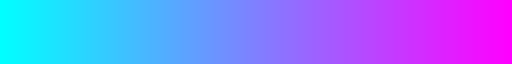

In [ ]:
cmap = colormaps["cool"]
cmap

So cool points correspond to early host-times, and hot ones, to late host-times.

<InteractiveFigure width=100% height=800>
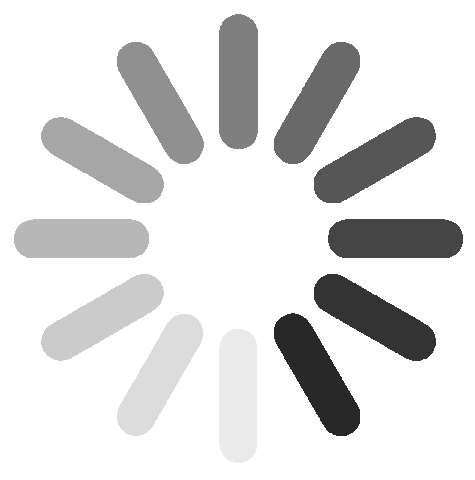

In [ ]:
ts_min, ts_max = processes_x_host_time["timestamp"].agg(["min", "max"])
delta = ts_max - ts_min
dmp.create_interactive_plot(
    pxht_dmap,
    labels,
    hover_text=hover_text,
    title="Hosts over time",
    sub_title="as distributions over a cloud of command line vectors",
    darkmode=True,
    color_label_text=False,
    marker_color_array=[cmap((ts - ts_min) / delta) for ts in processes_x_host_time["timestamp"]],
    enable_search=True
)

In [ ]:
processes_x_host_time["hostname"].unique()

array(['ACME-DC1', 'ACME-HH-AKA', 'ACME-HH-AXF', 'ACME-HH-AZH',
       'ACME-HH-CCF', 'ACME-HH-CLR', 'ACME-HH-DFN', 'ACME-HH-EAY',
       'ACME-HH-HGC', 'ACME-HH-IQS', 'ACME-HH-MBY', 'ACME-HH-OLY',
       'ACME-HH-TTW', 'ACME-HH-UWI', 'ACME-HH-YIM', 'ACME-WS-AZU',
       'ACME-WS-NUQ', 'ACME-WS-PLU', 'ACME-WS-PRV', 'ACME-WS-UVF',
       'ACME-HH-ATV', 'ACME-HH-IKA', 'ACME-HH-KKN', 'ACME-HH-TON',
       'ACME-HH-BVW'], dtype=object)

At a glance, we see that no software workload is time specific:
all regions of the space host points running the whole color range.
This visualization makes it difficult to track how hosts cover the space;
a quick look around hovering over points suggest that most hosts
carry workloads all over the space, given time.
None of these hosts manifests any specialized behaviour:
they just zoom around the space over time.
This is surprising at first blush, given that at least one of these hosts,
`ACME-DC1`, is the Domain Controller of the network &mdash; a rather specific role.
The generic shape of its behaviour likely stems from the network being small and barely used compared to a regular enterprise network.
As such, the DC services a handful of authentication queries per day,
making it look just like any other workstation on the network.